# CS351L - Introduction to Machine Learning


- Introduction to Machine Learning
- Linear Regression
- Cost Function
- Gradient Descent for Optimization

## Learning Objectives

By the end of this lab, you should be able to:

1. Explain what Machine Learning is.
2. Understand the difference between features and targets.
3. Explain the idea of Linear Regression.
4. Use a linear equation to make predictions.
5. Understand prediction error and the Cost Function.
6. Explain how Gradient Descent optimizes model parameters.
7. Implement Linear Regression from scratch using Python and NumPy.
8. Visualize the learning process.
9. Compare a manual implementation with Scikit-learn.

## Introduction to Machine Learning

Machine Learning (ML) is a branch of Artificial Intelligence that allows
computers to learn patterns from data and make predictions or decisions
without being explicitly programmed for every possible situation.

### Traditional Programming

Input Data + Rules → Output

Example:
- If temperature > 30°C, print "Hot".
- Otherwise, print "Not Hot".

### Machine Learning

Input Data + Known Outputs → Learning Algorithm → Learned Model

The model learns a relationship between inputs and outputs from examples.

### Example

Suppose we have data about houses:

| House Size (m²) | Price |
|---|---|
| 50 | 100,000 |
| 75 | 150,000 |
| 100 | 200,000 |
| 125 | 250,000 |

A Machine Learning algorithm can learn the relationship between house size
and price.

After learning, it may predict the price of a new 90 m² house.

### Important Terms

- Dataset: A collection of data.
- Feature (X): An input variable used to make predictions.
- Target / Label (y): The value we want to predict.
- Model: A mathematical representation of a learned relationship.
- Training: The process of learning from data.
- Prediction: The output produced by the trained model.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Used later for comparison
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

print("Libraries imported successfully!")

Libraries imported successfully!


## Example Dataset: House Size and Price

Our goal is to predict house prices based on house size.

### Feature (X)
House size in square meters.

### Target (y)
House price in thousands of dollars.

For example:

- A house of 50 m² costs approximately 100 thousand dollars.
- A house of 100 m² costs approximately 200 thousand dollars.

We will begin with a small dataset so that we can understand the mathematics
before using a larger dataset.

In [2]:
# House size in square meters
X = np.array([50, 75, 100, 125, 150], dtype=float)

# House price in thousands of dollars
y = np.array([100, 150, 200, 250, 300], dtype=float)

print("X (House Size):", X)
print("y (House Price):", y)

X (House Size): [ 50.  75. 100. 125. 150.]
y (House Price): [100. 150. 200. 250. 300.]


In [3]:
# Create a DataFrame for a clearer view

data = pd.DataFrame({
    "House Size (m²)": X,
    "Price (Thousands)": y
})

data

,House Size (m²),Price (Thousands)
0,50.0,100.0
1,75.0,150.0
2,100.0,200.0
3,125.0,250.0
4,150.0,300.0


## Visualizing the Relationship

Before building a model, we should inspect the data.

A scatter plot shows individual observations.

- The x-axis represents the feature.
- The y-axis represents the target.
- Each dot represents one example from our dataset.

If the points approximately follow a straight-line pattern, Linear Regression
may be a suitable starting model.

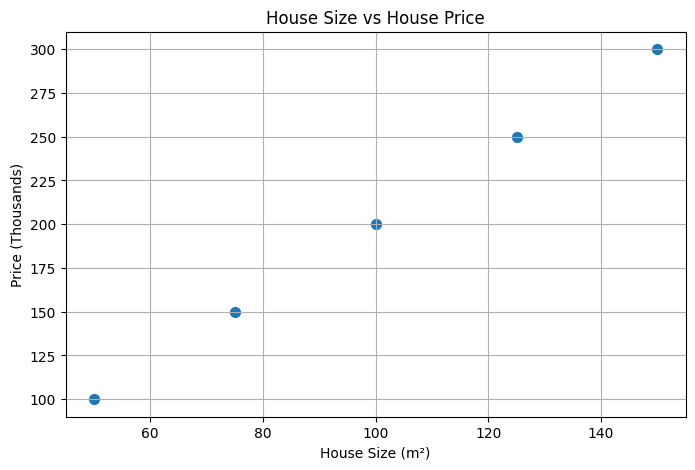

In [9]:
plt.figure(figsize=(8, 5))

plt.scatter(X, y, s=50)

plt.xlabel("House Size (m²)")
plt.ylabel("Price (Thousands)")
plt.title("House Size vs House Price")
plt.grid(True)

plt.show()

##  Linear Regression

Linear Regression is a supervised Machine Learning algorithm used to predict
a continuous numerical value.

Examples:
- Predicting house prices
- Predicting salary
- Predicting temperature
- Predicting sales
- Predicting electricity consumption

### Main Idea

Linear Regression tries to find a straight line that best represents the
relationship between the input and the output.

For one feature, the equation is:

ŷ = wx + b

Where:

- x = Input feature
- ŷ = Predicted output
- w = Weight / Slope
- b = Bias / Intercept

The model learns suitable values of w and b from the training data.

## Understanding ŷ = wx + b

Let's use the following equation:

ŷ = 2x + 5

Here:

w = 2
b = 5

Suppose x = 10.

ŷ = 2(10) + 5
ŷ = 25

Therefore, the predicted output is 25.

### What does w mean?

w controls the slope of the line.

- A larger positive w makes the line rise more steeply.
- A negative w makes the line decrease.
- A w close to zero makes the line flatter.

### What does b mean?

b is the intercept.

It tells us the predicted value when x = 0.

### What does x mean?

x is the input feature given to the model.

### What does ŷ mean?

ŷ is the output predicted by the model.

In [10]:
# Example parameters
w = 2
b = 5

# Input
x = 10

# Prediction
y_hat = w * x + b

print("Predicted output:", y_hat)

Predicted output: 25


## Creating a Prediction Function

Instead of writing:

ŷ = wx + b

every time, we can create a Python function.

The function will:
1. Receive x, w, and b.
2. Calculate wx + b.
3. Return the prediction.

In [11]:
def predict(x, w, b):
    """
    Calculate predictions using the linear equation:
    ŷ = wx + b
    """
    return w * x + b

In [12]:
# Test the function

w = 2
b = 5

prediction = predict(10, w, b)

print("Prediction:", prediction)

Prediction: 25


## Predicting Multiple Values

A model usually receives many input values.

For example, we may want to predict prices for several house sizes at once.

NumPy allows us to perform the same calculation on an entire array.

In [17]:
# Example model parameters
w = 2
b = 0

# Predictions for all house sizes
predictions = predict(X, w, b)

results = pd.DataFrame({
    "House Size": X,
    "Actual Price": y,
    "Predicted Price": predictions
})

results

,House Size,Actual Price,Predicted Price
0,50.0,100.0,100.0
1,75.0,150.0,150.0
2,100.0,200.0,200.0
3,125.0,250.0,250.0
4,150.0,300.0,300.0


## Prediction Error

A prediction is not always equal to the actual value.

The prediction error tells us how far the prediction is from the actual target.

### Error

Error = Actual Value - Predicted Value

Mathematically:

e = y - ŷ

Where:

- y = Actual value
- ŷ = Predicted value
- e = Error

### Example

Actual price = 200
Predicted price = 180

Error = 200 - 180
Error = 20

The model underpredicted by 20.

### Another Example

Actual price = 200
Predicted price = 220

Error = 200 - 220
Error = -20

The model overpredicted by 20.

A negative error does not mean the error is bad or good.
It only indicates the direction of the prediction error.

In [18]:
# Let's use the previous predictions
errors = y - predictions

error_table = pd.DataFrame({
    "House Size": X,
    "Actual Price": y,
    "Predicted Price": predictions,
    "Error (y - ŷ)": errors
})

error_table

,House Size,Actual Price,Predicted Price,Error (y - ŷ)
0,50.0,100.0,100.0,0.0
1,75.0,150.0,150.0,0.0
2,100.0,200.0,200.0,0.0
3,125.0,250.0,250.0,0.0
4,150.0,300.0,300.0,0.0


## Cost Function

The Cost Function measures how well a model's predictions match the actual
values.

It gives us one number that represents the overall prediction error.

For Linear Regression, we commonly use Mean Squared Error (MSE).

### Mean Squared Error

MSE = (1/n) Σ (yᵢ - ŷᵢ)²

Where:

- n = Number of training examples
- yᵢ = Actual value for example i
- ŷᵢ = Predicted value for example i
- (yᵢ - ŷᵢ) = Prediction error

### Why Square the Error?

1. Negative errors become positive.
2. Large errors receive more penalty.
3. Errors can be averaged into one value.

### Interpretation

- Smaller MSE → Predictions are generally closer to actual values.
- Larger MSE → Predictions are generally farther from actual values.

The goal of training is to find model parameters that minimize the cost.

In [19]:
# Calculate Mean Squared Error manually

squared_errors = (y - predictions) ** 2

mse = np.mean(squared_errors)

print("Squared errors:", squared_errors)
print("Mean Squared Error:", mse)

Squared errors: [0. 0. 0. 0. 0.]
Mean Squared Error: 0.0


In [20]:
def compute_cost(X, y, w, b):
    """
    Compute the Linear Regression cost function.

    J(w,b) = (1 / 2n) * sum((ŷ - y)^2)

    Parameters:
    X : Input features
    y : Actual target values
    w : Weight / slope
    b : Bias / intercept

    Returns:
    Cost value
    """

    n = len(y)

    predictions = w * X + b
    errors = predictions - y

    cost = (1 / (2 * n)) * np.sum(errors ** 2)

    return cost

In [21]:
# Calculate cost for our current model

w = 2
b = 0

cost = compute_cost(X, y, w, b)

print("Cost:", cost)

Cost: 0.0


## Comparing Different Parameter Values

Let's calculate the cost for several different lines.

Each line has a different w and b.

We will ask:

- Which line produces the smallest cost?
- Does a lower cost generally mean the line fits the data better?
- Can we find the best parameters by trying values?

This is the basic idea behind optimization.

In [22]:
# Try different parameter combinations

parameter_combinations = [
    (0, 0),
    (1, 0),
    (2, 0),
    (2.5, 0),
    (1.5, 10),
    (2, 5)
]

cost_results = []

for w, b in parameter_combinations:
    cost = compute_cost(X, y, w, b)
    cost_results.append([w, b, cost])

cost_table = pd.DataFrame(
    cost_results,
    columns=["w", "b", "Cost"]
)

cost_table

,w,b,Cost
0,0.0,0,22500.00
1,1.0,0,5625.00
2,2.0,0,0.00
3,2.5,0,1406.25
4,1.5,10,956.25
5,2.0,5,12.50


## Visualizing Predictions and Errors

Let's select one candidate model.

We will plot:

- Actual data points.
- The predicted regression line.
- Vertical gaps between actual and predicted values.

These vertical gaps represent prediction errors.

The cost function uses these errors to calculate an overall measure of model
performance.

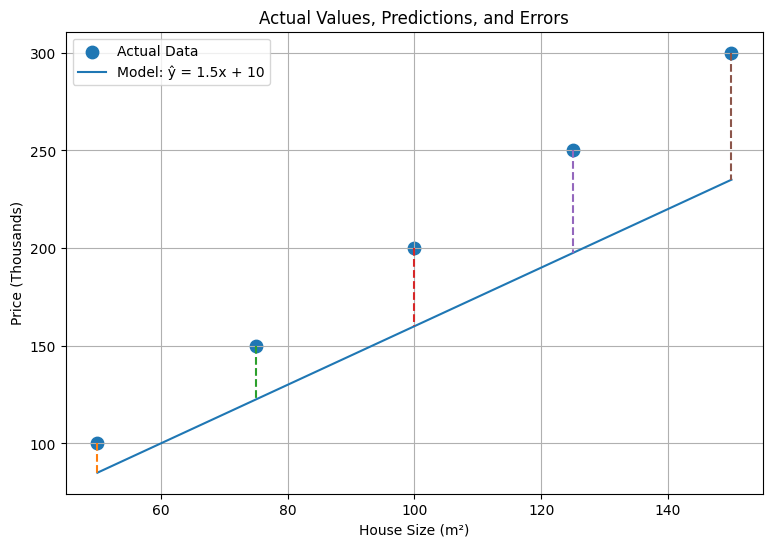

Cost: 956.25


In [23]:
# Select a candidate model
w = 1.5
b = 10

predictions = predict(X, w, b)

plt.figure(figsize=(9, 6))

# Actual data
plt.scatter(X, y, s=80, label="Actual Data")

# Candidate regression line
x_line = np.linspace(X.min(), X.max(), 100)
y_line = predict(x_line, w, b)

plt.plot(x_line, y_line, label=f"Model: ŷ = {w}x + {b}")

# Draw error lines
for x_i, y_actual, y_pred in zip(X, y, predictions):
    plt.plot(
        [x_i, x_i],
        [y_actual, y_pred],
        linestyle="--"
    )

plt.xlabel("House Size (m²)")
plt.ylabel("Price (Thousands)")
plt.title("Actual Values, Predictions, and Errors")
plt.legend()
plt.grid(True)

plt.show()

print("Cost:", compute_cost(X, y, w, b))

## Why Do We Need Optimization?

We know that:

1. A model makes predictions.
2. The cost function measures prediction error.
3. We want to minimize the cost.

But how do we find the best values of w and b?

One possibility is to try many values:

w = -10, -9.9, -9.8, ..., 10
b = -10, -9.9, -9.8, ..., 10

However, this becomes inefficient when:
- There are many parameters.
- The dataset is large.
- The model is more complicated.

Instead, we use an optimization algorithm.

One of the most important optimization algorithms is:

# Gradient Descent

## Gradient Descent — Intuition

Imagine standing on a mountain in thick fog.

You cannot see the entire landscape, but you want to reach the lowest point.

You can:
1. Look at the slope near your current position.
2. Determine which direction goes downhill.
3. Take a small step downhill.
4. Repeat until you reach a low point.

Gradient Descent works similarly.

Instead of minimizing height, it minimizes the Cost Function.

- Current position → Current parameter values (w and b)
- Height → Cost
- Slope → Gradient
- Step size → Learning Rate
- Lowest point → Minimum cost

### Main Idea

Update the parameters in the direction that reduces the cost.

## What Is a Gradient?

A gradient tells us how the cost changes when a parameter changes.

For our model, we have two parameters:

- w
- b

Therefore, we calculate two gradients:

- ∂J/∂w
- ∂J/∂b

These tell us how the cost changes with respect to w and b.

### Interpretation

If the gradient is positive:
- Increasing the parameter tends to increase the cost.
- We generally move the parameter in the opposite direction.

If the gradient is negative:
- Increasing the parameter tends to decrease the cost.
- The update may increase the parameter.

Gradient Descent always moves opposite to the gradient.

## One Gradient Descent Step

Before implementing the full algorithm, let's understand the sequence.

Suppose:

w = 0
b = 0

For each training example:

1. Calculate the prediction:
   ŷᵢ = wxᵢ + b

2. Calculate the error:
   errorᵢ = ŷᵢ - yᵢ

3. Calculate the gradients:
   ∂J/∂w = (1/n) Σ errorᵢxᵢ
   ∂J/∂b = (1/n) Σ errorᵢ

4. Update w and b:
   w = w - α(∂J/∂w)
   b = b - α(∂J/∂b)

5. Repeat.

Every iteration attempts to reduce the cost.

## Computing Gradients

We will create a function that calculates:

1. Predictions
2. Errors
3. Gradient with respect to w
4. Gradient with respect to b

This function will not update the parameters yet.

It only calculates the direction in which the parameters should move.

In [24]:
def compute_gradients(X, y, w, b):
    """
    Compute gradients for Linear Regression.

    ∂J/∂w = (1/n) * sum((ŷ - y) * X)
    ∂J/∂b = (1/n) * sum(ŷ - y)
    """

    n = len(y)

    predictions = w * X + b
    errors = predictions - y

    dj_dw = (1 / n) * np.sum(errors * X)
    dj_db = (1 / n) * np.sum(errors)

    return dj_dw, dj_db

In [29]:
# Initial parameter values
w = 0
b = 0

dj_dw, dj_db = compute_gradients(X, y, w, b)

print("Gradient with respect to w:", dj_dw)
print("Gradient with respect to b:", dj_db)

Gradient with respect to w: -22500.0
Gradient with respect to b: -200.0


## One Parameter Update

Now we will use the gradients to update w and b.

The update rules are:

w = w - learning_rate × gradient_w

b = b - learning_rate × gradient_b

We will begin with one update step.

In [26]:
# Initial parameters
w = 0.0
b = 0.0

# Learning rate
learning_rate = 0.0001

# Compute gradients
dj_dw, dj_db = compute_gradients(X, y, w, b)

# Update parameters
w_new = w - learning_rate * dj_dw
b_new = b - learning_rate * dj_db

print("Old w:", w)
print("New w:", w_new)

print("Old b:", b)
print("New b:", b_new)

Old w: 0.0
New w: 2.25
Old b: 0.0
New b: 0.02


## Feature Scaling

Gradient Descent works by updating parameters using gradients.

When feature values are very large, gradients can also become large.
This may make training unstable or require a very small learning rate.

Feature scaling changes the numerical range of the input values.

One common method is Standardization:

x_scaled = (x - mean(x)) / standard_deviation(x)

After standardization:
- The feature has approximately mean 0.
- The feature has approximately standard deviation 1.

Feature scaling does not change the underlying relationship in a problematic
way; it makes numerical optimization easier.

Important:
We scale the feature values, not the meaning of the original problem.

In [30]:
# Calculate mean and standard deviation
X_mean = np.mean(X)
X_std = np.std(X)

# Standardize X
X_scaled = (X - X_mean) / X_std

print("Original X:", X)
print("Scaled X:", X_scaled)

print("Mean of scaled X:", np.mean(X_scaled))
print("Standard deviation of scaled X:", np.std(X_scaled))

Original X: [ 50.  75. 100. 125. 150.]
Scaled X: [-1.41421356 -0.70710678  0.          0.70710678  1.41421356]
Mean of scaled X: 0.0
Standard deviation of scaled X: 0.9999999999999999


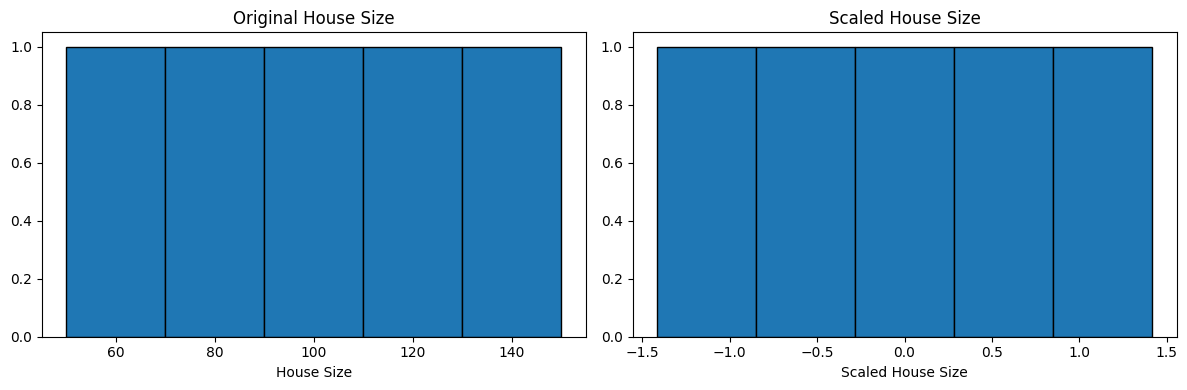

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(X, bins=5, edgecolor="black")
axes[0].set_title("Original House Size")
axes[0].set_xlabel("House Size")

axes[1].hist(X_scaled, bins=5, edgecolor="black")
axes[1].set_title("Scaled House Size")
axes[1].set_xlabel("Scaled House Size")

plt.tight_layout()
plt.show()

## Full Gradient Descent Algorithm

Our algorithm will repeat the following steps:

1. Start with initial values of w and b.
2. Calculate predictions.
3. Calculate the cost.
4. Calculate gradients.
5. Update w and b.
6. Store the cost.
7. Repeat for a fixed number of iterations.

### What Is an Iteration?

One iteration means one complete parameter update.

### What Is an Epoch?

In this simple batch gradient descent example, one epoch can refer to one
complete pass through the training data.

Here, each iteration uses the entire dataset to calculate the gradients.

In [32]:
def gradient_descent(X, y, w_initial, b_initial, learning_rate, iterations):
    """
    Perform Batch Gradient Descent for Linear Regression.

    Parameters
    ----------
    X : numpy array
        Input features
    y : numpy array
        Actual target values
    w_initial : float
        Initial weight
    b_initial : float
        Initial bias
    learning_rate : float
        Step size for parameter updates
    iterations : int
        Number of updates

    Returns
    -------
    w : float
        Learned weight
    b : float
        Learned bias
    cost_history : list
        Cost recorded at each iteration
    """

    w = w_initial
    b = b_initial

    cost_history = []

    for i in range(iterations):

        # Step 1: Calculate gradients
        dj_dw, dj_db = compute_gradients(X, y, w, b)

        # Step 2: Update parameters
        w = w - learning_rate * dj_dw
        b = b - learning_rate * dj_db

        # Step 3: Calculate and store cost
        cost = compute_cost(X, y, w, b)
        cost_history.append(cost)

    return w, b, cost_history

## Training Our First Model

We will now train Linear Regression using Gradient Descent.

Because we are using scaled features, we can use a more practical learning
rate.

Initial parameters:

w = 0
b = 0

The algorithm will gradually adjust these values to reduce the cost.

In [33]:
# Initial parameters
w_initial = 0.0
b_initial = 0.0

# Hyperparameters
learning_rate = 0.1
iterations = 1000

# Train the model
w_scaled, b_scaled, cost_history = gradient_descent(
    X_scaled,
    y,
    w_initial,
    b_initial,
    learning_rate,
    iterations
)

print("Learned weight:", w_scaled)
print("Learned bias:", b_scaled)
print("Initial cost:", cost_history[0])
print("Final cost:", cost_history[-1])

Learned weight: 70.71067811865471
Learned bias: 199.9999999999999
Initial cost: 18225.0
Final cost: 7.12877822830124e-27


## Hyperparameters

Hyperparameters are values we choose before training.

Examples:
- Learning rate
- Number of iterations

They are not directly learned from the training data in this implementation.

### Learning Rate

Controls the size of each update.

### Number of Iterations

Controls how many times the algorithm updates the parameters.

A suitable combination helps the model converge toward a low-cost solution.

## Cost Reduction During Training

We stored the cost after every iteration.

Let's visualize it.

If Gradient Descent is working correctly, the cost should generally decrease
as training progresses.

This graph helps us understand whether the model is learning.

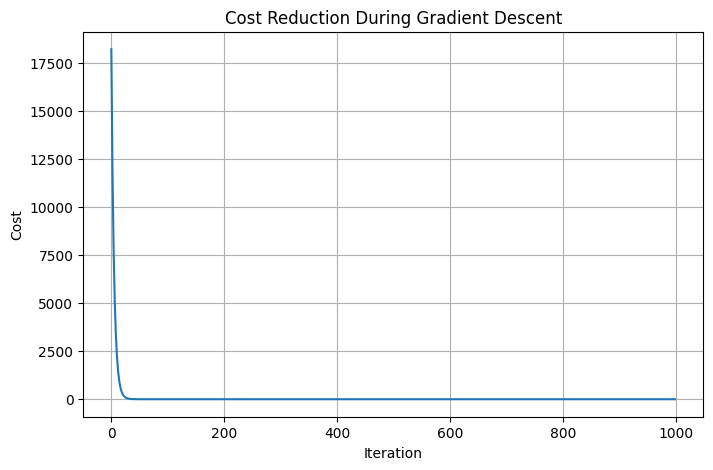

In [34]:
plt.figure(figsize=(8, 5))

plt.plot(cost_history)

plt.xlabel("Iteration")
plt.ylabel("Cost")
plt.title("Cost Reduction During Gradient Descent")
plt.grid(True)

plt.show()

## Inspecting the Learning Process

Let's inspect the cost at selected iterations.

This helps us see how much the model improves during training.

In [35]:
selected_iterations = [0, 1, 2, 5, 10, 50, 100, 500, 999]

for i in selected_iterations:
    print(f"Iteration {i + 1}: Cost = {cost_history[i]:.6f}")

Iteration 1: Cost = 18225.000000
Iteration 2: Cost = 14762.250000
Iteration 3: Cost = 11957.422500
Iteration 6: Cost = 6354.664571
Iteration 11: Cost = 2215.734530
Iteration 51: Cost = 0.484081
Iteration 101: Cost = 0.000013
Iteration 501: Cost = 0.000000
Iteration 1000: Cost = 0.000000


## Generate Predictions

Our model was trained using scaled X values.

Therefore, when making predictions, we must also use scaled input values.

The learned equation is:

ŷ = w_scaled × X_scaled + b_scaled

We will use this equation to calculate predictions.

In [36]:
# Generate predictions using the trained model
predictions_scaled = predict(X_scaled, w_scaled, b_scaled)

results = pd.DataFrame({
    "House Size (m²)": X,
    "Actual Price": y,
    "Predicted Price": predictions_scaled
})

results

,House Size (m²),Actual Price,Predicted Price
0,50.0,100.0,100.0
1,75.0,150.0,150.0
2,100.0,200.0,200.0
3,125.0,250.0,250.0
4,150.0,300.0,300.0


## Visualizing the Trained Model

We will plot:
- The original data points.
- The regression line learned by Gradient Descent.

Although the model was trained using scaled features, we can visualize the
predictions against the original house sizes.

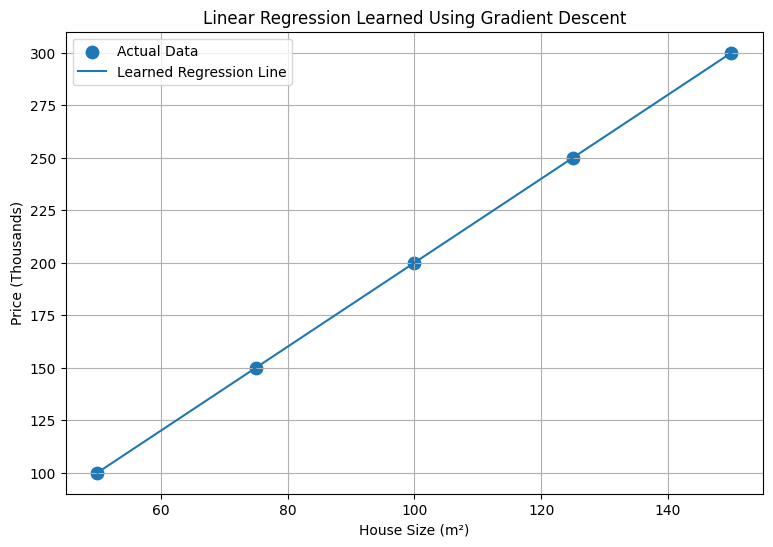

In [37]:
# Create smooth original x values
x_line = np.linspace(X.min(), X.max(), 100)

# Scale the smooth x values using training mean and std
x_line_scaled = (x_line - X_mean) / X_std

# Predict using trained parameters
y_line = predict(x_line_scaled, w_scaled, b_scaled)

plt.figure(figsize=(9, 6))

plt.scatter(X, y, s=80, label="Actual Data")
plt.plot(x_line, y_line, label="Learned Regression Line")

plt.xlabel("House Size (m²)")
plt.ylabel("Price (Thousands)")
plt.title("Linear Regression Learned Using Gradient Descent")
plt.legend()
plt.grid(True)

plt.show()

## Evaluating the Model

We can calculate evaluation metrics to understand how well the model fits
the data.

### Mean Squared Error (MSE)

Measures the average squared prediction error.

Lower MSE generally indicates better predictions.

### Root Mean Squared Error (RMSE)

RMSE = √MSE

RMSE is in the same units as the target.

For example, if the target is house price in thousands, RMSE is also in
thousands.

### R² Score

R² measures how much of the variation in the target is explained by the model.

A value closer to 1 generally indicates a better fit for this type of
regression evaluation.

Important:
A high R² on a small or simple dataset does not automatically mean the model
will perform well on unseen real-world data.

In [38]:
# Calculate evaluation metrics

mse = np.mean((y - predictions_scaled) ** 2)
rmse = np.sqrt(mse)

# R² calculated manually
ss_total = np.sum((y - np.mean(y)) ** 2)
ss_residual = np.sum((y - predictions_scaled) ** 2)

r2 = 1 - (ss_residual / ss_total)

print("Mean Squared Error:", mse)
print("Root Mean Squared Error:", rmse)
print("R² Score:", r2)

Mean Squared Error: 1.4257556456602478e-26
Root Mean Squared Error: 1.1940501018216312e-13
R² Score: 1.0


## Experiment: Change the Learning Rate

The learning rate controls the size of each update.

Let's compare several learning rates.

Try:

- Very small learning rate
- Suitable learning rate
- Very large learning rate

Observe the cost curves.

### Questions to Think About

1. What happens when the learning rate is too small?
2. What happens when it is too large?
3. Does the cost always decrease?
4. Why might a large learning rate cause instability?

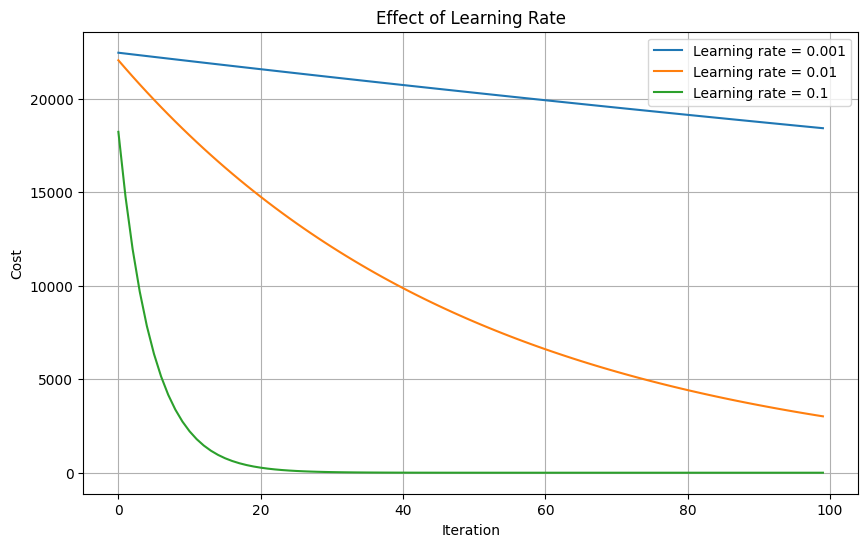

In [ ]:
learning_rates = [0.001, 0.01, 0.1]

plt.figure(figsize=(10, 6))

for lr in learning_rates:
    _, _, history = gradient_descent(
        X_scaled,
        y,
        0.0,
        0.0,
        lr,
        100
    )

    plt.plot(history, label=f"Learning rate = {lr}")

plt.xlabel("Iteration")
plt.ylabel("Cost")
plt.title("Effect of Learning Rate")
plt.legend()
plt.grid(True)

plt.show()

## Experiment: Change the Number of Iterations

The number of iterations determines how many times Gradient Descent updates
the parameters.

Compare:

- 10 iterations
- 100 iterations
- 1000 iterations

A small number of iterations may not be enough for the model to reach a low
cost.

However, more iterations do not always guarantee better generalization on
unseen data.

In [39]:
iteration_values = [10, 100, 1000]

for num_iterations in iteration_values:
    w_temp, b_temp, history_temp = gradient_descent(
        X_scaled,
        y,
        0.0,
        0.0,
        0.1,
        num_iterations
    )

    print(f"Iterations: {num_iterations}")
    print(f"  Weight: {w_temp:.4f}")
    print(f"  Bias: {b_temp:.4f}")
    print(f"  Final Cost: {history_temp[-1]:.6f}")
    print()

Iterations: 10
  Weight: 46.0554
  Bias: 130.2643
  Final Cost: 2735.474728

Iterations: 100
  Weight: 70.7088
  Bias: 199.9947
  Final Cost: 0.000016

Iterations: 1000
  Weight: 70.7107
  Bias: 200.0000
  Final Cost: 0.000000



## Linear Regression Using Scikit-learn

So far, we implemented Linear Regression manually using NumPy.

In real projects, we often use established libraries such as Scikit-learn.

Scikit-learn provides a ready-to-use LinearRegression model.

The general workflow is:

1. Create the model.
2. Fit the model using training data.
3. Use the model to make predictions.
4. Evaluate the predictions.

We will compare its results with our implementation.

In [40]:
# Scikit-learn expects X to be a 2D array
X_2d = X.reshape(-1, 1)

# Create the model
sk_model = LinearRegression()

# Train the model
sk_model.fit(X_2d, y)

# Make predictions
sk_predictions = sk_model.predict(X_2d)

print("Scikit-learn weight:", sk_model.coef_[0])
print("Scikit-learn bias:", sk_model.intercept_)

Scikit-learn weight: 1.999999999999999
Scikit-learn bias: 1.1368683772161603e-13


In [41]:
comparison = pd.DataFrame({
    "House Size": X,
    "Actual Price": y,
    "Gradient Descent Prediction": predictions_scaled,
    "Scikit-learn Prediction": sk_predictions
})

comparison

,House Size,Actual Price,Gradient Descent Prediction,Scikit-learn Prediction
0,50.0,100.0,100.0,100.0
1,75.0,150.0,150.0,150.0
2,100.0,200.0,200.0,200.0
3,125.0,250.0,250.0,250.0
4,150.0,300.0,300.0,300.0


In [42]:
manual_mse = mean_squared_error(y, predictions_scaled)
sklearn_mse = mean_squared_error(y, sk_predictions)

manual_r2 = r2_score(y, predictions_scaled)
sklearn_r2 = r2_score(y, sk_predictions)

comparison_metrics = pd.DataFrame({
    "Model": ["Manual Gradient Descent", "Scikit-learn"],
    "MSE": [manual_mse, sklearn_mse],
    "R² Score": [manual_r2, sklearn_r2]
})

comparison_metrics

,Model,MSE,R² Score
0,Manual Gradient Descent,1.425756e-26,1.0
1,Scikit-learn,1.615587e-27,1.0


## Linear Regression with Noisy Data

Real-world data rarely follows a perfectly straight line.

Measurements may contain:
- Human errors
- Environmental effects
- Missing factors
- Random variation
- Measurement noise

Let's create a dataset where the relationship is approximately linear but not
perfect.

In [ ]:
np.random.seed(42)

# Generate feature values
X_noisy = np.arange(1, 21, dtype=float)

# Generate target values with noise
noise = np.random.normal(0, 8, size=len(X_noisy))
y_noisy = 5 * X_noisy + 10 + noise

noisy_data = pd.DataFrame({
    "X": X_noisy,
    "y": y_noisy
})

noisy_data.head()

,X,y
0,1.0,18.973713
1,2.0,18.893886
2,3.0,30.181508
3,4.0,42.184239
4,5.0,33.126773


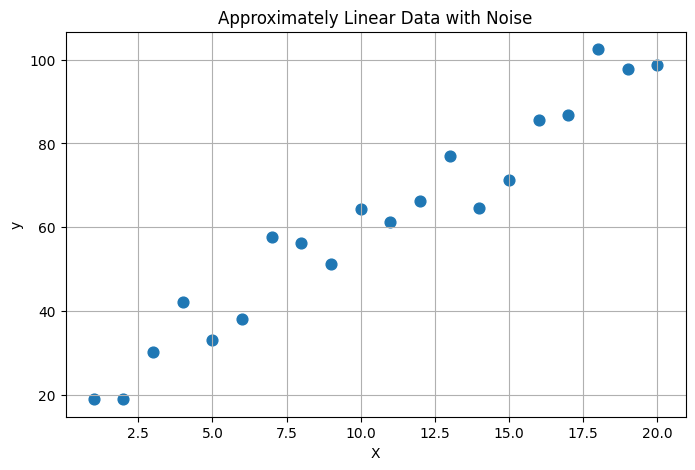

In [ ]:
plt.figure(figsize=(8, 5))

plt.scatter(X_noisy, y_noisy, s=60)

plt.xlabel("X")
plt.ylabel("y")
plt.title("Approximately Linear Data with Noise")
plt.grid(True)

plt.show()

## Training on Noisy Data

This time, the data points will not lie exactly on a straight line.

The goal of Linear Regression is not necessarily to pass through every point.

Instead, it tries to find a line that minimizes the overall cost.

In [ ]:
# Standardize the noisy feature
X_noisy_mean = np.mean(X_noisy)
X_noisy_std = np.std(X_noisy)

X_noisy_scaled = (X_noisy - X_noisy_mean) / X_noisy_std

# Train
w_noisy, b_noisy, noisy_cost_history = gradient_descent(
    X_noisy_scaled,
    y_noisy,
    0.0,
    0.0,
    0.1,
    1000
)

# Predictions
y_noisy_pred = predict(X_noisy_scaled, w_noisy, b_noisy)

print("Learned weight:", w_noisy)
print("Learned bias:", b_noisy)
print("Final cost:", noisy_cost_history[-1])

Learned weight: 24.238459300207833
Learned bias: 61.12961150846534
Final cost: 17.470716998262155


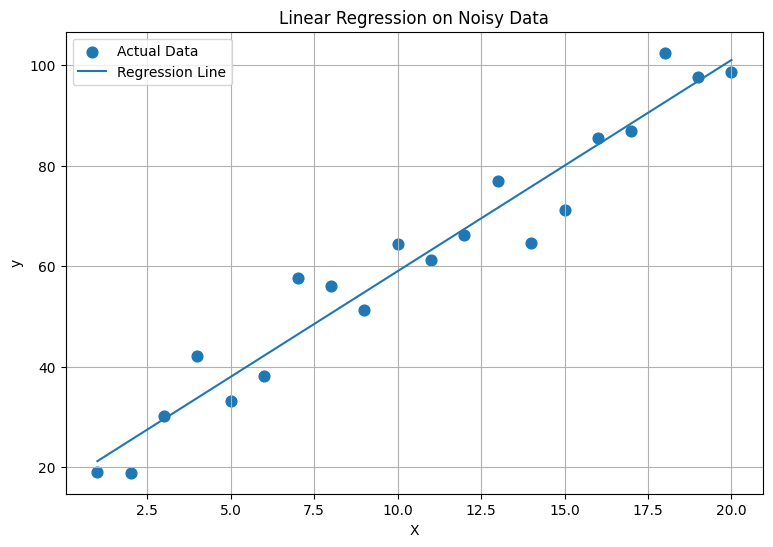

In [ ]:
x_noisy_line = np.linspace(X_noisy.min(), X_noisy.max(), 100)
x_noisy_line_scaled = (x_noisy_line - X_noisy_mean) / X_noisy_std

y_noisy_line = predict(
    x_noisy_line_scaled,
    w_noisy,
    b_noisy
)

plt.figure(figsize=(9, 6))

plt.scatter(X_noisy, y_noisy, s=60, label="Actual Data")
plt.plot(x_noisy_line, y_noisy_line, label="Regression Line")

plt.xlabel("X")
plt.ylabel("y")
plt.title("Linear Regression on Noisy Data")
plt.legend()
plt.grid(True)

plt.show()

## Complete Machine Learning Workflow

Let's summarize the workflow we followed.

### Step 1: Collect Data
We started with house sizes and prices.

### Step 2: Identify Features and Target
- X = House size
- y = House price

### Step 3: Visualize the Data
We used a scatter plot to inspect the relationship.

### Step 4: Choose a Model
We selected Linear Regression because the relationship was approximately linear.

### Step 5: Initialize Parameters
We started with initial values for w and b.

### Step 6: Make Predictions
We used:

ŷ = wx + b

### Step 7: Calculate Cost
We measured prediction error using:

J(w,b) = (1 / 2n) Σ (ŷᵢ - yᵢ)²

### Step 8: Calculate Gradients
We determined how the cost changes with respect to w and b.

### Step 9: Update Parameters
We used Gradient Descent:

w := w - α(∂J/∂w)
b := b - α(∂J/∂b)

### Step 10: Repeat
We repeated the process to reduce the cost.

### Step 11: Evaluate
We calculated metrics such as MSE, RMSE, and R².

### Step 12: Visualize Results
We plotted the learned regression line and predictions.